# 환경설정

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install koreanize_matplotlib
import koreanize_matplotlib



from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier

# 경고 무시
import warnings
warnings.filterwarnings('ignore')



# 데이터설명

- 공유오피스 서비스의 2년 8개월치(2021.05.01 ~ 2023.12.31) 데이터
- 테이블명/테이블 설명/테이블별 주요 컬럼

|#	|테이블명|	테이블 설명|	주요컬럼|
|---|----|---|---|
|1	|trial_register|	3일체험 신청|	유저id, 3일체험신청일시|
|2	|trial_visit_info|	3일체험 신청자 일자별 방문기록|	유저id, 날짜, 지점id, 최초입실시각, 최종퇴실시각, 체류시간|
|3	|trial_access_log|	3일체험 신청자 출입기록|	유저id, 지점id, timestamp, 출입방향|
|4	|trial_payment|	3일체험 신청자 결제 여부|	유저id, 결제여부|
|5	|site_area|	지점별 면적|	지점id, 지점 면적|

# 데이터 불러오기

In [ ]:
register_df = pd.read_csv('/content/drive/MyDrive/4팀/01_데이터/원본 데이터/trial_register.csv')
visit_df = pd.read_csv('/content/drive/MyDrive/4팀/01_데이터/원본 데이터/trial_visit_info.csv')
access_df = pd.read_csv('/content/drive/MyDrive/4팀/01_데이터/원본 데이터/trial_access_log.csv')
pay_df = pd.read_csv('/content/drive/MyDrive/4팀/01_데이터/원본 데이터/trial_payment.csv')
area_df = pd.read_csv('/content/drive/MyDrive/4팀/01_데이터/원본 데이터/site_area.csv')

# 데이터 전처리

- 모든테이블 공통으로 할 전처리
    - 날짜관련컬럼 datetime으로 변경 일단위까지만 사용
    - 모든 결측치 drop으로 처리 -> 정보가 없어 모델링에 노이즈임
    - user_id로 컬럼명 변경

- register_df -> 1명의 유저 1번 체험신청 할 수 있게 중복신청 제거
    - 신규 가입자는 딱 1번 3일 체험을 이용할 수 있음에도 불구하고
    - 같은 날 2회 3일 체험을 신청하거나
    - 서로 다른 날 2회 3일 체험을 신청한 경우가 존재
- visit_df
    - `stay_time`은 `stay_second`과 겹쳐서 삭제처리
    - `first_enter_time` & `last_leave_time` 데이터 결점 많아 사용할 수 없음 판단
- access_df
    - visit테이블과 맞지 않아 사용하지 않기로 결정함
- payment_df
    - user_id 결측치 중복값만 처리
- area_df
    - 그대로 사용

### 전처리 코드

### register_df

In [ ]:
# 중복값 제거
register_df.drop_duplicates(inplace=True)

# 1. register_df: format을 빼거나 유연하게 처리
register_df['trial_date'] = pd.to_datetime(register_df['trial_date'], errors='coerce')

# 신청 2번한 유저 필터링
filtered_df = register_df[
    register_df.groupby('user_uuid')['user_uuid'].transform('count') == 2
]

# 2. 시간순으로 정렬
register_df = register_df.sort_values('trial_date')
register_df = register_df.reset_index(drop=True)


# 컬럼이름 바꾸고
register_df.rename(columns={'user_uuid': 'user_id'}, inplace=True)

# 중복행 삭제
register_df = (
    register_df
    .drop_duplicates(subset='user_id', keep='last')
    .reset_index(drop=True)
)


### Visit_df

In [ ]:
# 모든값 중복된 행 조회 & 중복행제거
visit_df[visit_df.duplicated(keep=False)]
visit_df.drop_duplicates(inplace=True)

# 결측치 제거
visit_df = visit_df.dropna(subset=['first_enter_time', 'last_leave_time'])

# 'date' 컬럼 변환
visit_df['date'] = pd.to_datetime(visit_df['date'], errors='coerce').dt.date

# 1. 숫자(초) 컬럼을 사용하여 Timedelta로 변환 (가장 안전)
visit_df['stay_time'] = pd.to_timedelta(visit_df['stay_time_second'], unit='s')

# 두컬럼은 이슈가 좀 있어서, CSV파일로 포멧좀 바꿔주고
cols = ['first_enter_time', 'last_leave_time']

for col in cols:
    visit_df[col] = pd.to_datetime(visit_df[col], errors='coerce')

# 결측치 확인
print(visit_df[cols].isnull().sum())

# 컬럼이름 바꾸고
visit_df.rename(columns={'user_uuid': 'user_id'}, inplace=True)

first_enter_time    792
last_leave_time     769
dtype: int64


### accees_df 확인절차

In [ ]:
# access_df 유저 1명의 데이터 체류시간이 visit_df의 stay_second와 일치 하지 않음
userA = access_df[access_df['user_id'] == "cacd0adb-2c87-450f-8a00-2b2ea6b8fa89"]
userA = userA.sort_values(by='cdate', ascending=True)
userA

### pay_df

In [ ]:
pay_df[pay_df.duplicated(keep=False)]
pay_df.drop_duplicates(inplace=True)
# 컬럼이름 바꾸고
pay_df.rename(columns={'user_uuid': 'user_id'}, inplace=True)

In [ ]:
# visit_df datetime 변환
cols = ['first_enter_time', 'last_leave_time', 'date']
for col in cols:
    visit_df[col] = pd.to_datetime(visit_df[col])

# Timedelta로 변환
visit_df['stay_time'] = pd.to_timedelta(visit_df['stay_time_second'], unit='s')

# 결측치 확인
print(visit_df[cols].isnull().sum())

first_enter_time    792
last_leave_time     769
date                  0
dtype: int64


In [ ]:
# 이상치 제거
Q1 = visit_df['stay_time_second'].quantile(0.25)
Q3 = visit_df['stay_time_second'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_iqr = visit_df[(visit_df['stay_time_second'] >= lower_bound) & (visit_df['stay_time_second'] <= upper_bound)]
df_iqr

,site_id,date,stay_time,stay_time_second,first_enter_time,last_leave_time,user_id
0,1,2023-12-23,0 days 01:11:19,4279,2023-12-23 16:11:25.345793,2023-12-23 17:25:32.233995,939fc566-61cd-47f0-a3ce-e2936fdcff73
1,1,2023-12-24,0 days 04:35:10,16510,2023-12-24 16:10:45.668026,2023-12-24 20:53:34.842447,939fc566-61cd-47f0-a3ce-e2936fdcff73
2,1,2023-12-25,0 days 02:09:54,7794,2023-12-25 10:19:47.087268,2023-12-25 12:39:51.221372,939fc566-61cd-47f0-a3ce-e2936fdcff73
3,1,2023-12-23,0 days 04:37:36,16656,2023-12-23 14:49:40.302823,2023-12-23 19:27:39.406803,ba49324f-d317-4053-adf9-2b17b3f07594
4,3,2023-12-26,0 days 04:32:05,16325,2023-12-26 14:57:10.220793,2023-12-26 19:34:36.971542,ba49324f-d317-4053-adf9-2b17b3f07594
...,...,...,...,...,...,...,...
11472,6,2022-06-16,0 days 06:47:59,24479,2022-06-16 11:00:48.643935,2022-06-16 18:23:38.495290,766221e7-a753-444f-aa5a-ae76ce86d3fd
11473,6,2022-06-17,0 days 01:28:46,5326,2022-06-17 17:15:05.221223,2022-06-17 18:56:00.840639,0a70277f-a7f9-401c-95fa-ed6d96ee32e0
11474,6,2022-06-16,0 days 05:08:03,18483,2022-06-16 12:52:46.557742,2022-06-16 18:23:34.355309,0a70277f-a7f9-401c-95fa-ed6d96ee32e0
11475,6,2023-02-06,0 days 06:30:29,23429,2023-02-06 10:14:00.538281,2023-02-06 16:52:37.606175,576473bb-0647-483e-b06a-a5ff6491b08b


In [ ]:
# 필요없는 컬럼 드랍
df = df_iqr.drop(columns=['stay_time', 'first_enter_time', 'last_leave_time'])
df['user_id'].nunique()

6151

In [ ]:
# 1. 각 유저별로 stay_time_second가 가장 큰 행의 site_id를 미리 추출합니다.
# 유저별로 체류시간 내림차순 정렬 후 첫 번째 행(최댓값)만 남깁니다.
top_site_info = df.sort_values(['user_id', 'stay_time_second'], ascending=[True, False]) \
                  .drop_duplicates('user_id')[['user_id', 'site_id']] \
                  .rename(columns={'site_id': 'max_stay_site_id'})

# 2. 유저별로 필요한 통계량들을 집계(agg)합니다.
user_stats = df.groupby('user_id').agg(
    stay_min=('stay_time_second', 'min'),
    stay_max=('stay_time_second', 'max'),
    stay_mean=('stay_time_second', 'mean'),
    stay_sum=('stay_time_second', 'sum'),
    visit_days=('date', 'nunique')
).reset_index()

# 3. 집계 결과와 최장 체류 사이트 정보를 결합합니다.
user_stats = user_stats.merge(top_site_info, on='user_id', how='left')

# 결과 확인
user_stats.head()

,user_id,stay_min,stay_max,stay_mean,stay_sum,visit_days,max_stay_site_id
0,000590dc-046f-462b-8225-4c81a97b7166,21417,21417,21417.000000,21417,1,6
1,000be14f-ba0f-4af6-bc2c-7b00dfcbc98c,9382,25965,15189.666667,45569,3,3
2,0018e22d-a2cc-4e06-bca2-d6a041770f3b,34472,42900,38686.000000,77372,2,6
3,002606d9-38ca-48f3-910c-cbfada9a9109,12335,12689,12512.000000,25024,2,17
4,002a7570-90dd-4cab-b0aa-b0e40f7ef27a,4887,18722,11804.500000,23609,2,5


### Merge

In [ ]:
# register_df와 user_stats를 user_id 컬럼을 기준으로 left merge 수행
final_df = register_df.merge(user_stats, on='user_id', how='left')

# 결과 확인
final_df.head()

,trial_date,user_id,stay_min,stay_max,stay_mean,stay_sum,visit_days,max_stay_site_id
0,2021-05-01,badbde4d-886b-4992-a8e3-fd0c05640183,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-05-01,e079e682-62f2-4c05-84b9-86913e3dc146,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-05-01,f25078d1-1030-485c-85c5-dc82d6987043,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-05-01,844319ff-cd15-4633-9900-6eaf4dc68b68,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-05-01,9f5e2bd3-65c9-4800-84c1-f5c93f44d096,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# 컬럼이름 바꾸고
final_df.rename(columns={'max_stay_site_id': 'site_id'}, inplace=True)

# 2. 병합
final_df = final_df.merge(area_df, on='site_id', how='left')
final_df

,trial_date,user_id,stay_min,stay_max,stay_mean,stay_sum,visit_days,site_id,area_pyeong
0,2021-05-01,badbde4d-886b-4992-a8e3-fd0c05640183,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-05-01,e079e682-62f2-4c05-84b9-86913e3dc146,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-05-01,f25078d1-1030-485c-85c5-dc82d6987043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-05-01,844319ff-cd15-4633-9900-6eaf4dc68b68,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-05-01,9f5e2bd3-65c9-4800-84c1-f5c93f44d096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
9619,2023-12-30,e9b1a5df-d70c-4ccf-af22-64fdae98d3a2,11929.0,14360.0,12977.333333,38932.0,3.0,4.0,100.0
9620,2023-12-30,aa4773c8-dbc9-4c80-849b-1ab8d1db7bda,11831.0,11831.0,11831.000000,11831.0,1.0,3.0,150.0
9621,2023-12-31,acf3e288-4487-492b-9477-df149fb72e83,14525.0,23817.0,19171.000000,38342.0,2.0,6.0,150.0
9622,2023-12-31,0e58ea5a-ebe4-48cb-b31b-d02a4f350cf8,10710.0,27812.0,19261.000000,38522.0,2.0,3.0,150.0


In [ ]:
# year, month컬럼 생성
final_df['year'] = final_df['trial_date'].dt.year
final_df['month'] = final_df['trial_date'].dt.month

In [ ]:
# 2. 병합
final_df = final_df.merge(pay_df, on='user_id', how='left')
final_df

,trial_date,user_id,stay_min,stay_max,stay_mean,stay_sum,visit_days,site_id,area_pyeong,year,month,is_payment
0,2021-05-01,badbde4d-886b-4992-a8e3-fd0c05640183,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021,5,1
1,2021-05-01,e079e682-62f2-4c05-84b9-86913e3dc146,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021,5,0
2,2021-05-01,f25078d1-1030-485c-85c5-dc82d6987043,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021,5,1
3,2021-05-01,844319ff-cd15-4633-9900-6eaf4dc68b68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021,5,1
4,2021-05-01,9f5e2bd3-65c9-4800-84c1-f5c93f44d096,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...
9619,2023-12-30,e9b1a5df-d70c-4ccf-af22-64fdae98d3a2,11929.0,14360.0,12977.333333,38932.0,3.0,4.0,100.0,2023,12,0
9620,2023-12-30,aa4773c8-dbc9-4c80-849b-1ab8d1db7bda,11831.0,11831.0,11831.000000,11831.0,1.0,3.0,150.0,2023,12,0
9621,2023-12-31,acf3e288-4487-492b-9477-df149fb72e83,14525.0,23817.0,19171.000000,38342.0,2.0,6.0,150.0,2023,12,0
9622,2023-12-31,0e58ea5a-ebe4-48cb-b31b-d02a4f350cf8,10710.0,27812.0,19261.000000,38522.0,2.0,3.0,150.0,2023,12,1


# 머신러닝

In [ ]:
df = final_df.dropna()
# 필요없는 컬럼 드랍
pro_merge_df = df.drop(columns=['trial_date', 'user_id', 'visit_days'])
pro_merge_df

,stay_min,stay_max,stay_mean,stay_sum,site_id,area_pyeong,year,month,is_payment
556,15574.0,15574.0,15574.000000,15574.0,3.0,150.0,2021,6,1
564,7558.0,7558.0,7558.000000,7558.0,3.0,150.0,2021,6,1
566,11547.0,11547.0,11547.000000,11547.0,3.0,150.0,2021,6,1
569,2907.0,8741.0,5824.000000,11648.0,2.0,100.0,2021,6,1
577,5975.0,6809.0,6392.000000,12784.0,2.0,100.0,2021,6,1
...,...,...,...,...,...,...,...,...,...
9619,11929.0,14360.0,12977.333333,38932.0,4.0,100.0,2023,12,0
9620,11831.0,11831.0,11831.000000,11831.0,3.0,150.0,2023,12,0
9621,14525.0,23817.0,19171.000000,38342.0,6.0,150.0,2023,12,0
9622,10710.0,27812.0,19261.000000,38522.0,3.0,150.0,2023,12,1


In [ ]:


y_rf = pro_merge_df['is_payment'].astype(int)
X_rf = pro_merge_df.drop(columns=['is_payment'])

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf,
    test_size=0.2,
    random_state=42,
    stratify=y_rf # train/test 분할 시 타깃(y)의 클래스 비율을 그대로 유지
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features="sqrt", # 분할에 사용할 feature(변수)를 몇 개까지 보게 할지 = √(전체 피처 수)
    class_weight="balanced",
    random_state=42,
    n_jobs=-1 # 현재 머신의 모든 CPU 코어 사용
)
rf.fit(X_train_rf, y_train_rf)

y_pred_rf = rf.predict(X_test_rf)
print("\nClassification Report:\n", classification_report(y_test_rf, y_pred_rf, digits=4))


Classification Report:
               precision    recall  f1-score   support

           0     0.6919    0.5682    0.6240       755
           1     0.4664    0.5987    0.5244       476

    accuracy                         0.5800      1231
   macro avg     0.5792    0.5835    0.5742      1231
weighted avg     0.6047    0.5800    0.5855      1231



## 하이퍼파라미터튜닝

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV

y_rf = pro_merge_df['is_payment'].astype(int)
X_rf = pro_merge_df.drop(columns=['is_payment'])

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42, stratify=y_rf
)

rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# 빠른 탐색 범위 (튜닝은 가볍게 → 확정 후 n_estimators만 키우기)
param_dist_fast = {
    "n_estimators": [200, 300, 400, 600],
    "max_depth": [3, 5, 7, 10, 15],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", "log2", 0.5, 0.7],
    "bootstrap": [True],
    "max_samples": [0.6, 0.8, 1.0]   # 속도/성능 모두에 도움
}

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_fast,
    n_iter=15,              # 15~20 추천
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train_rf, y_train_rf)

best_rf = search.best_estimator_
print("Best params:", search.best_params_)
print("Best CV score:", search.best_score_)

y_pred_rf = best_rf.predict(X_test_rf)
print("\nClassification Report:\n", classification_report(y_test_rf, y_pred_rf, digits=4))

Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_samples': 0.6, 'max_features': 'sqrt', 'max_depth': 15, 'bootstrap': True}
Best CV score: 0.6115853658536585

Classification Report:
               precision    recall  f1-score   support

           0     0.6659    0.7258    0.6946       755
           1     0.4926    0.4223    0.4548       476

    accuracy                         0.6084      1231
   macro avg     0.5793    0.5740    0.5747      1231
weighted avg     0.5989    0.6084    0.6018      1231



## n_estimators

In [ ]:
# 트리 개수에 따른 성능 변화
y_rf = pro_merge_df['is_payment'].astype(int)
X_rf = pro_merge_df.drop(columns=['is_payment'])

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42, stratify=y_rf
)

n_trees_list = [1, 5, 10, 20, 50, 100, 200]
rows = []

for n_trees in n_trees_list:
    rf = RandomForestClassifier(
        n_estimators=n_trees,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )
    rf.fit(X_train_rf, y_train_rf)

    y_train_pred = rf.predict(X_train_rf)
    y_test_pred = rf.predict(X_test_rf)

    rows.append({
        "n_estimators": n_trees,
        "train_accuracy": rf.score(X_train_rf, y_train_rf),
        "test_accuracy": rf.score(X_test_rf, y_test_rf),
        "test_recall": recall_score(y_test_rf, y_test_pred),
        "test_precision": precision_score(y_test_rf, y_test_pred, zero_division=0),
        "test_f1": f1_score(y_test_rf, y_test_pred)
    })

pd.DataFrame(rows).round(4)

,n_estimators,train_accuracy,test_accuracy,test_recall,test_precision,test_f1
0,1,0.8360,0.5865,0.4643,0.4653,0.4648
1,5,0.9494,0.5930,0.3845,0.4680,0.4221
2,10,0.9720,0.6044,0.3193,0.4825,0.3843
3,20,0.9921,0.6174,0.3466,0.5077,0.4120
4,50,1.0000,0.6068,0.3466,0.4882,0.4054
5,100,1.0000,0.6109,0.3529,0.4956,0.4123
6,200,1.0000,0.6060,0.3508,0.4869,0.4078


- recall이 안정화된 수치를 보았을 때 `n_estimatores=100` 으로 채택

## max_depth

In [ ]:
depths = [1, 2, 3, 4, 5, 7, 10, None]
results = []

for depth in depths:
    tree_temp = RandomForestClassifier(
        max_depth=depth,
        class_weight="balanced",
        random_state=42
    )
    tree_temp.fit(X_train_rf, y_train_rf)

    train_acc = tree_temp.score(X_train_rf, y_train_rf)
    test_acc = tree_temp.score(X_test_rf, y_test_rf)
    y_test_pred = tree_temp.predict(X_test_rf)
    test_recall = recall_score(y_test_rf, y_test_pred)


    results.append({
        "max_depth": depth if depth is not None else "제한없음",
        "train_acc": round(train_acc, 4),
        "test_acc": round(test_acc, 4),
        "test_recall": round(test_recall, 4)
    })

results_df = pd.DataFrame(results)
results_df

,max_depth,train_acc,test_acc,test_recall
0,1,0.5445,0.5280,0.6744
1,2,0.5598,0.5402,0.6492
2,3,0.5764,0.5516,0.6345
3,4,0.5941,0.5662,0.6155
4,5,0.6159,0.5735,0.6071
5,7,0.6852,0.5906,0.5693
6,10,0.8394,0.6019,0.4958
7,제한없음,1.0000,0.6109,0.3529


- recall이 max_depth=4 이후로 급격히 감소. 따라서 `max_depth=3`채택

## min_samples_split

In [ ]:
splits = [2, 5, 10, 20, 30]
results_split = []

for split in splits:
    tree_temp = RandomForestClassifier(
        min_samples_split=split,
        class_weight="balanced",
        random_state=42
    )
    tree_temp.fit(X_train_rf, y_train_rf)

    train_acc = tree_temp.score(X_train_rf, y_train_rf)
    test_acc = tree_temp.score(X_test_rf, y_test_rf)
    y_test_pred = tree_temp.predict(X_test_rf)
    test_recall = recall_score(y_test_rf, y_test_pred)


    results_split.append({
        "min_samples_split": split,
        "train_acc": round(train_acc, 4),
        "test_acc": round(test_acc, 4),
        "test_recall": round(test_recall, 4)
    })

results_split_df = pd.DataFrame(results_split)
results_split_df

,min_samples_split,train_acc,test_acc,test_recall
0,2,1.0000,0.6109,0.3529
1,5,0.9945,0.6190,0.4181
2,10,0.9478,0.6068,0.4433
3,20,0.8650,0.6076,0.4769
4,30,0.8089,0.5930,0.4874


- test_recall이 크게 좋아진 `min_samples_split=20` 채택

## min_samples_leaf

In [ ]:
leafs = [1, 5, 10, 15, 20]
results_leaf = []

for leaf in leafs:
    tree_temp = RandomForestClassifier(
        min_samples_leaf=leaf,
        class_weight="balanced",
        random_state=42
    )
    tree_temp.fit(X_train_rf, y_train_rf)

    train_acc = tree_temp.score(X_train_rf, y_train_rf)
    test_acc = tree_temp.score(X_test_rf, y_test_rf)
    y_test_pred = tree_temp.predict(X_test_rf)
    test_recall = recall_score(y_test_rf, y_test_pred)

    results_leaf.append({
        "min_samples_leaf": leaf,
        "train_acc": round(train_acc, 4),
        "test_acc": round(test_acc, 4),
        "test_recall": round(test_recall, 4)
    })

results_leaf_df = pd.DataFrame(results_leaf)
results_leaf_df

,min_samples_leaf,train_acc,test_acc,test_recall
0,1,1.0000,0.6109,0.3529
1,5,0.8760,0.5906,0.4643
2,10,0.7734,0.5971,0.5000
3,15,0.7272,0.5922,0.5168
4,20,0.7039,0.5865,0.5231


- test_recall이 안정적인 수치로 유지되고 test_acc 수치도 크게 떨어지지 않은 `min_samples_leaf=15` 채택

## 하이퍼파라미터튜닝 결과

In [ ]:
rf_final = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    min_samples_split=20,
    min_samples_leaf=15,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train_rf, y_train_rf)

y_pred_final = rf_final.predict(X_test_rf)
print("\nClassification Report:\n", classification_report(y_test_rf, y_pred_final, digits=4))


Classification Report:
               precision    recall  f1-score   support

           0     0.6869    0.5086    0.5845       755
           1     0.4479    0.6324    0.5244       476

    accuracy                         0.5565      1231
   macro avg     0.5674    0.5705    0.5544      1231
weighted avg     0.5945    0.5565    0.5612      1231



## Feature importance 확인

In [ ]:
importances = rf_final.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": X_train_rf.columns,
    "importance": importances
}).sort_values("importance", ascending=False)

feature_importance_df.head(15)

,feature,importance
0,stay_min,0.320087
2,stay_mean,0.268490
1,stay_max,0.146819
3,stay_sum,0.135649
7,month,0.055847
6,year,0.036936
4,site_id,0.022303
5,area_pyeong,0.013871


## Threshold 조정

In [ ]:
y_proba = rf_final.predict_proba(X_test_rf)[:, 1]

# 2) threshold 범위
thresholds = np.arange(0.1, 0.71, 0.05)

rows = []
for t in thresholds:
    y_pred = (y_proba >= t).astype(int)

    rows.append({
        "threshold": round(float(t), 2),
        "recall": round(recall_score(y_test_rf, y_pred), 4),
        "precision": round(precision_score(y_test_rf, y_pred, zero_division=0), 4),
        "f1": round(f1_score(y_test_rf, y_pred), 4),
        "positive_rate": round(y_pred.mean(), 4)  # 1로 예측한 비율
    })

threshold_df = pd.DataFrame(rows)
threshold_df

,threshold,recall,precision,f1,positive_rate
0,0.10,1.0000,0.3867,0.5577,1.0000
1,0.15,1.0000,0.3867,0.5577,1.0000
2,0.20,1.0000,0.3867,0.5577,1.0000
3,0.25,1.0000,0.3867,0.5577,1.0000
4,0.30,1.0000,0.3867,0.5577,1.0000
5,0.35,0.9958,0.3885,0.5590,0.9911
6,0.40,0.9202,0.4000,0.5576,0.8895
7,0.45,0.7731,0.4235,0.5472,0.7059
8,0.50,0.6324,0.4479,0.5244,0.5459
9,0.55,0.3887,0.5331,0.4496,0.2819


- threshold=0.45이후로 recall값이 급감하기 때문에  `threshold=0.4`로 채택

In [ ]:
y_pred_final = (rf_final.predict_proba(X_test_rf)[:, 1] >= 0.40).astype(int)

print(confusion_matrix(y_test_rf, y_pred_final))
print(classification_report(y_test_rf, y_pred_final, digits=4))

[[ 98 657]
 [ 38 438]]
              precision    recall  f1-score   support

           0     0.7206    0.1298    0.2200       755
           1     0.4000    0.9202    0.5576       476

    accuracy                         0.4354      1231
   macro avg     0.5603    0.5250    0.3888      1231
weighted avg     0.5966    0.4354    0.3505      1231



## confusion matrix 기반 모델 EDA

In [ ]:
y = pro_merge_df['is_payment'].astype(int)
X = pro_merge_df.drop(columns=['is_payment'])

# One-Hot encoding
X = pd.get_dummies(X, columns=["site_id"], drop_first=False)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
rf_final = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    min_samples_split=20,
    min_samples_leaf=15,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train, y_train)

y_pred_final = rf_final.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred_final, digits=4))


Classification Report:
               precision    recall  f1-score   support

           0     0.6882    0.4940    0.5752       755
           1     0.4456    0.6450    0.5270       476

    accuracy                         0.5524      1231
   macro avg     0.5669    0.5695    0.5511      1231
weighted avg     0.5944    0.5524    0.5566      1231



In [ ]:
y_pred_final = (rf_final.predict_proba(X_test)[:, 1] >= 0.40).astype(int)

print(confusion_matrix(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final, digits=4))

[[ 73 682]
 [ 27 449]]
              precision    recall  f1-score   support

           0     0.7300    0.0967    0.1708       755
           1     0.3970    0.9433    0.5588       476

    accuracy                         0.4240      1231
   macro avg     0.5635    0.5200    0.3648      1231
weighted avg     0.6012    0.4240    0.3208      1231



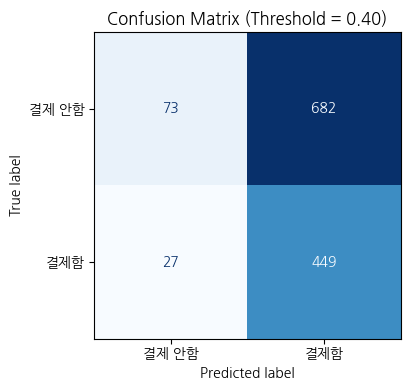

In [ ]:
y_proba = rf_final.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.40).astype(int)

# 2) Confusion Matrix 계산
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["결제 안함", "결제함"]
)
disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title("Confusion Matrix (Threshold = 0.40)")
plt.tight_layout()
plt.show()

### FN vs TP 비교

In [ ]:
eda_df = X_test.copy()
eda_df["y_true"] = y_test.values
eda_df["y_pred"] = y_pred
eda_df["y_proba"] = y_proba

# TP / FN 분리
tp_df = eda_df[(eda_df.y_true == 1) & (eda_df.y_pred == 1)]
fn_df = eda_df[(eda_df.y_true == 1) & (eda_df.y_pred == 0)]

In [ ]:
compare_df = pd.DataFrame({
    "TP_mean": tp_df.mean(numeric_only=True),
    "FN_mean": fn_df.mean(numeric_only=True)
})

compare_df["diff_FN_minus_TP"] = compare_df["FN_mean"] - compare_df["TP_mean"]
compare_df.sort_values("diff_FN_minus_TP", ascending=False)

,TP_mean,FN_mean,diff_FN_minus_TP
stay_sum,24304.287305,52421.222222,28116.934917
stay_min,9805.579065,26924.074074,17118.495009
stay_mean,12484.413660,28963.123457,16478.709797
stay_max,15199.864143,30859.814815,15659.950672
month,7.222717,7.814815,0.592098
year,2022.048998,2022.629630,0.580632
site_id_17.0,0.053452,0.222222,0.168770
site_id_49.0,0.008909,0.111111,0.102202
site_id_1.0,0.138085,0.185185,0.047101
site_id_2.0,0.149220,0.185185,0.035965


### FP vs TN 비교

In [ ]:
eda_df = X_test.copy()
eda_df["y_true"] = y_test.values
eda_df["y_pred"] = y_pred
eda_df["y_proba"] = y_proba

# TN / FP 분리
tn_df = eda_df[(eda_df.y_true == 0) & (eda_df.y_pred == 0)]
fp_df = eda_df[(eda_df.y_true == 0) & (eda_df.y_pred == 1)]

In [ ]:
compare_fp_tn_df = pd.DataFrame({
    "FP_mean": fp_df.mean(numeric_only=True),
    "TN_mean": tn_df.mean(numeric_only=True)
})

# FP - TN 차이 계산
compare_fp_tn_df["diff_FP_minus_TN"] = (
    compare_fp_tn_df["FP_mean"] - compare_fp_tn_df["TN_mean"]
)

# FP가 TN보다 높은 feature 정렬
compare_fp_tn_df_sorted = compare_fp_tn_df.sort_values(
    "diff_FP_minus_TN", ascending=False
)

compare_fp_tn_df_sorted

,FP_mean,TN_mean,diff_FP_minus_TN
area_pyeong,113.196481,104.109589,9.086892
y_pred,1.000000,0.000000,1.000000
y_proba,0.499642,0.381973,0.117669
site_id_3.0,0.193548,0.123288,0.070261
site_id_5.0,0.109971,0.041096,0.068875
site_id_4.0,0.070381,0.027397,0.042984
site_id_47.0,0.045455,0.027397,0.018057
y_true,0.000000,0.000000,0.000000
site_id_1.0,0.107038,0.109589,-0.002551
site_id_49.0,0.016129,0.054795,-0.038665


--- Summary Statistics ---
                TN_mean       FN_mean       TP_mean       FP_mean  TN_median  \
stay_min   27971.232877  26924.074074   9805.579065  11881.810850    27614.0   
stay_mean  29855.881279  28963.123457  12484.413660  14435.238319    29202.0   

              FN_median  TP_median     FP_median  
stay_min   27100.000000     8153.0  10980.000000  
stay_mean  28612.333333    11759.0  14241.333333  


<Figure size 1200x600 with 0 Axes>

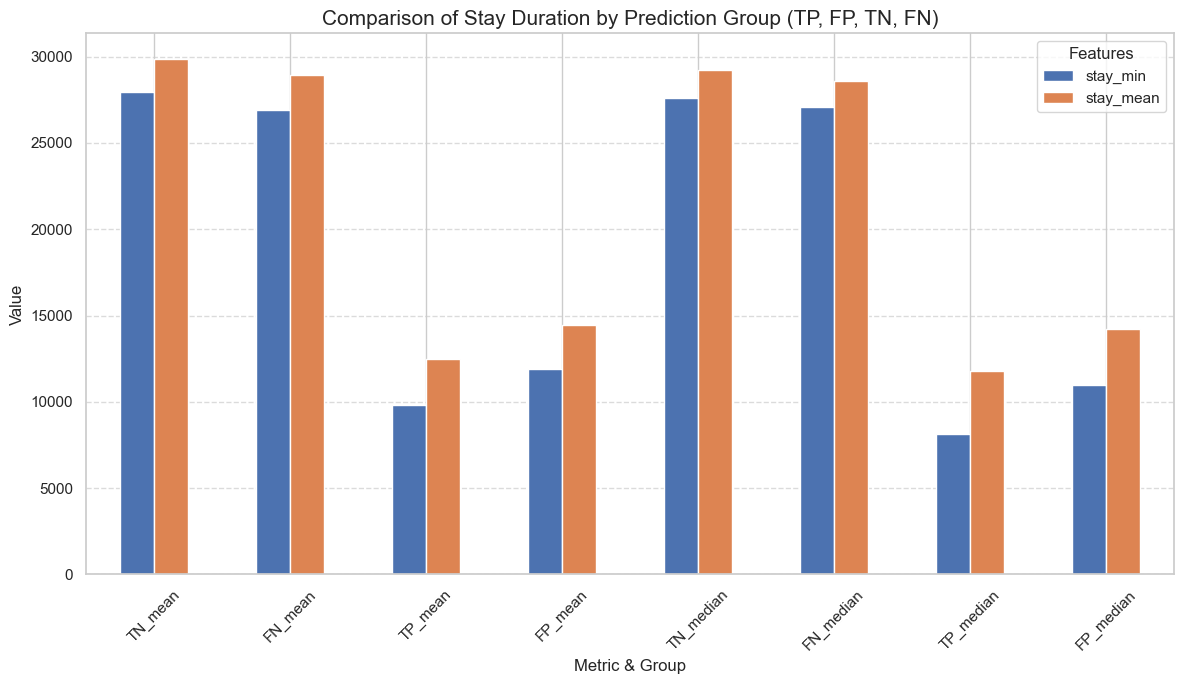

In [ ]:
# 1. Confusion Matrix 그룹 정의 (TP, FP, TN, FN)
tp_df = eda_df[(eda_df.y_true == 1) & (eda_df.y_pred == 1)]
fp_df = eda_df[(eda_df.y_true == 0) & (eda_df.y_pred == 1)]
tn_df = eda_df[(eda_df.y_true == 0) & (eda_df.y_pred == 0)]
fn_df = eda_df[(eda_df.y_true == 1) & (eda_df.y_pred == 0)]

# 2. 요약 통계량 데이터프레임 생성
summary = pd.DataFrame({
    'TN_mean': tn_df[['stay_min', 'stay_mean']].mean(),
    'FN_mean': fn_df[['stay_min', 'stay_mean']].mean(),
    'TP_mean': tp_df[['stay_min', 'stay_mean']].mean(),
    'FP_mean': fp_df[['stay_min', 'stay_mean']].mean(),
    'TN_median': tn_df[['stay_min', 'stay_mean']].median(),
    'FN_median': fn_df[['stay_min', 'stay_mean']].median(),
    'TP_median': tp_df[['stay_min', 'stay_mean']].median(),
    'FP_median': fp_df[['stay_min', 'stay_mean']].median()
})

print("--- Summary Statistics ---")
print(summary)

# 3. 시각화 (Visualization)
# 데이터를 시각화하기 편하도록 전치(Transpose)합니다.
plot_df = summary.T

# 스타일 설정
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# stay_min과 stay_mean을 나란히 비교하는 바 차트 생성
plot_df.plot(kind='bar', figsize=(12, 7))

plt.title('Comparison of Stay Duration by Prediction Group (TP, FP, TN, FN)', fontsize=15)
plt.xlabel('Metric & Group', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Features')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

# 두 그룹간 데이터 EDA

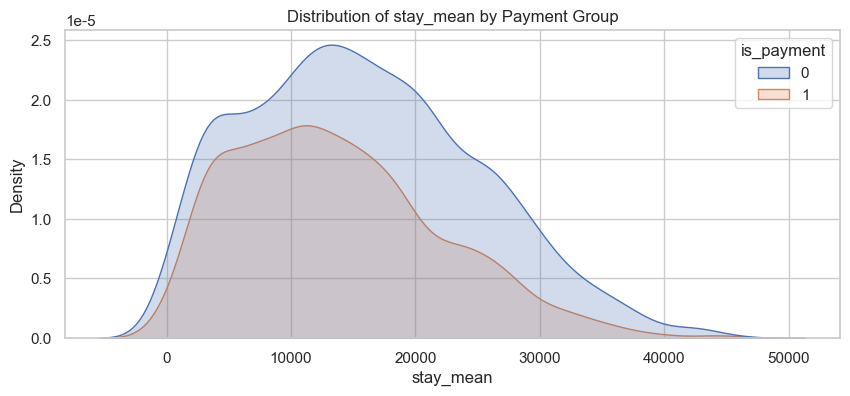

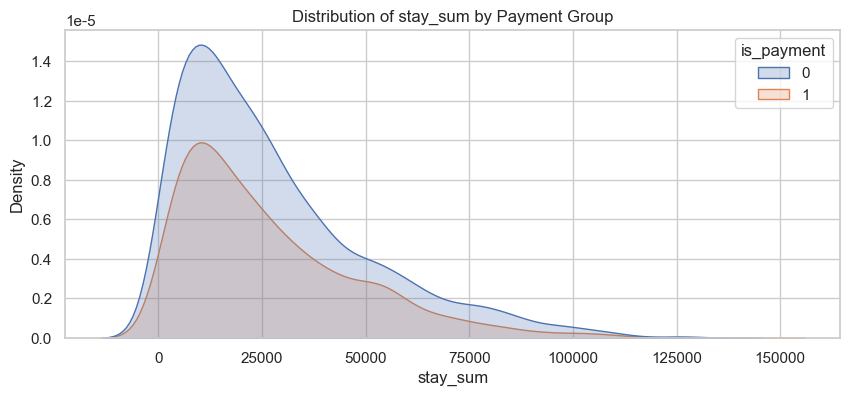

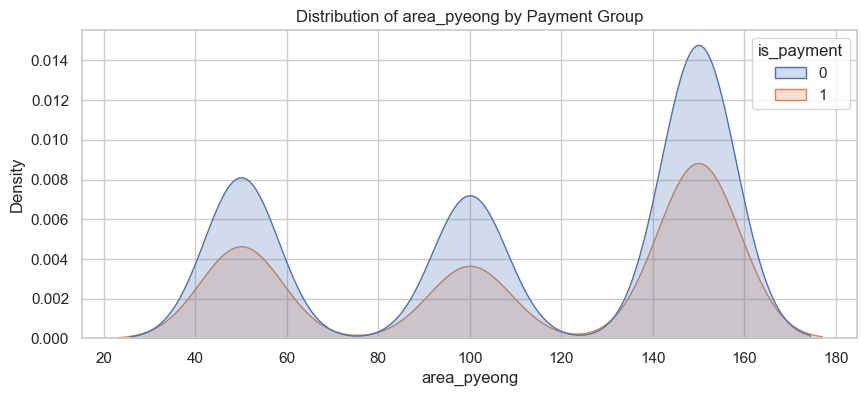

In [ ]:
cols_to_check = ['stay_mean', 'stay_sum', 'area_pyeong']

for col in cols_to_check:
    plt.figure(figsize=(10, 4))
    sns.kdeplot(data=df, x=col, hue='is_payment', fill=True)
    plt.title(f'Distribution of {col} by Payment Group')
    plt.show()

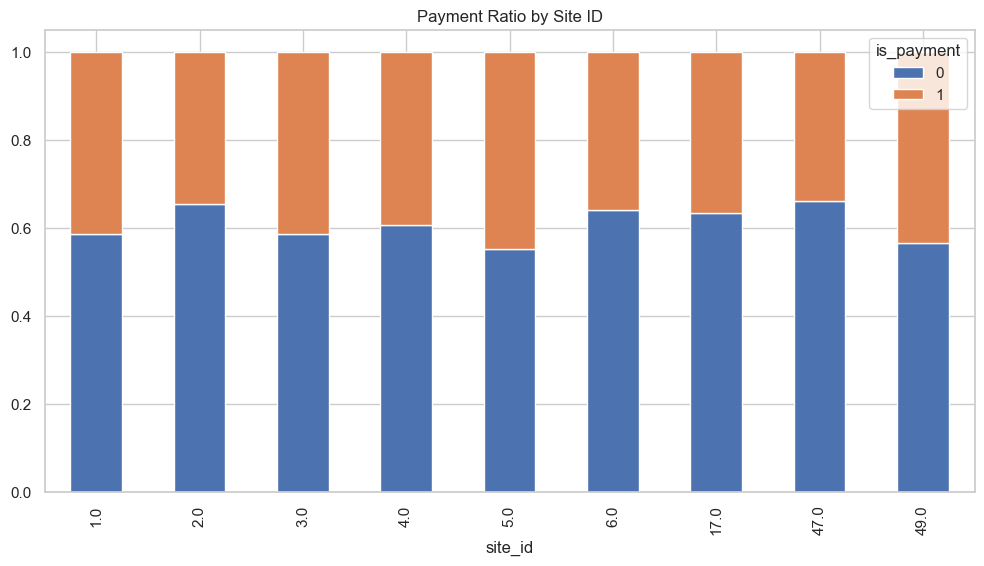

In [ ]:
# 사이트별 가입/미가입 빈도 계산
site_payment = df.groupby(['site_id', 'is_payment']).size().unstack().fillna(0)
# 비율로 변환 (%)
site_payment_ratio = site_payment.div(site_payment.sum(axis=1), axis=0)

site_payment_ratio.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Payment Ratio by Site ID')
plt.show()

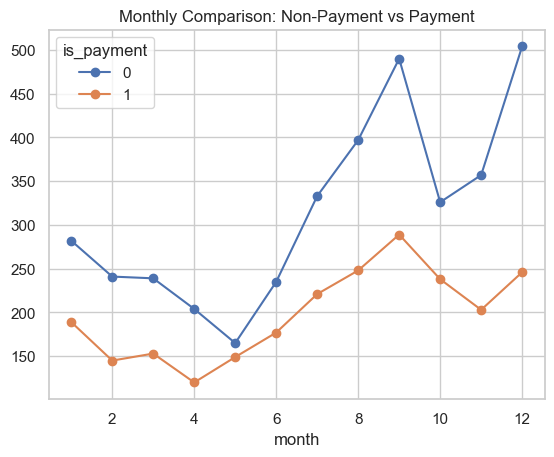

In [ ]:
# 월별 가입자 수 추이
monthly_trend = df.groupby(['month', 'is_payment']).size().unstack()
monthly_trend.plot(marker='o')
plt.title('Monthly Comparison: Non-Payment vs Payment')
plt.show()

In [ ]:
# 두 그룹의 주요 수치 평균 비교
comparison = df.groupby('is_payment')[['stay_mean', 'stay_sum', 'area_pyeong']].agg(['mean', 'median', 'std'])
display(comparison)

stay_mean                            stay_sum           \
                    mean   median          std          mean   median   
is_payment                                                              
0           15814.860010  15080.0  9221.782658  27821.054068  21417.0   
1           13731.629955  12627.0  8307.707554  26929.289319  20804.5   

                         area_pyeong                    
                     std        mean median        std  
is_payment                                              
0           23195.084430  111.078717  100.0  42.182975  
1           22068.956527  112.258200  150.0  42.632029

In [ ]:
from scipy import stats
df1 = df[df['is_payment'] == 1]
df0 = df[df['is_payment'] == 0]


# stay_mean에 대해 두 그룹 간 차이가 있는지 검정
t_stat, p_val = stats.ttest_ind(df1['stay_mean'], df0['stay_mean'])
print(f"P-value: {p_val}")


P-value: 4.227377562193486e-19


- 두 그룹간의 체류시간 차이가 통계적으로 유의미함

<Axes: xlabel='area_pyeong'>

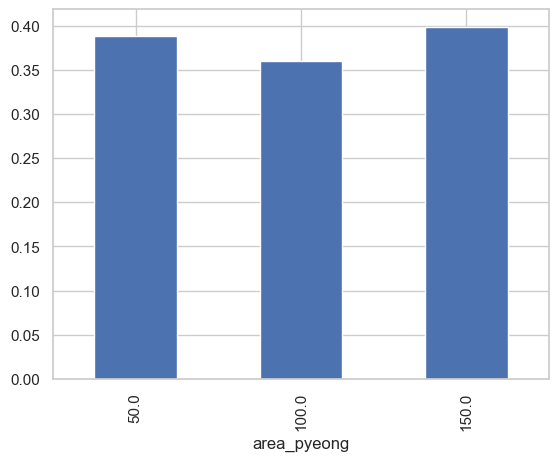

In [ ]:
# 평수별 가입률 계산
area_conversion = df.groupby('area_pyeong')['is_payment'].mean()
area_conversion.plot(kind='bar')

# 결과해석

## 모델설명

- Recall 수치를 높여 놓치는 고객을 없이 분류하기위해 Threshold값을 조절하였음
- 모델EDA 결과는 다음과 같음

❌ 체류 시간(stay_time)
→ “결제 행동”이 아니라 “탐색 성향”을 더 많이 설명

✅ 결제 연관 행동 패턴
→ 짧더라도 “결정에 가까운 행동”

- 왜 모델은 FN을 놓쳤는가?
- 모델의 학습 구조
    - RandomForest + shallow depth(max_depth=3)
    - Recall 중심 + threshold 0.4
    - 결제 직전 행동 패턴에 가중치를 둔 구조
- 짧고 목적성 있는 행동 → TP로 잘 잡힘
- 오래 머물며 탐색하는 행동 → TN 또는 FN으로 오인
- 이 모델은 ‘빠른 결제형 고객’에는 강하고‘고관여·장기 탐색형 고객’에는 약하다.
- 즉 이모델은 체류 시간이 길어질수록 결제하지 않는 고객으로 분류하고있음 이결과는 데이터 EDA에서 본 결과와 같음

## 데이터 EDA 결제(1) vs 미결제(0)

- 두 그룹의 데이터 체류시간의 분포를 봤지만 육안으로는 거의 식별 불가능할정도로 비슷한 분포를 보임
- 미결제 그룹의 체류시간이 조금 더 길었음 -> 두 그룹의 체류시간 차이가 통계적으로 유의미한 것을 확인


- ⭐ 최종결론
    - 체류시간과 평수외 다른 피쳐와 함께 유저의 결제여부를 예측하는 모델을 만들었으나, 결과적으로 현재 가지고있는 데이터로는 명확히 구분해내기 어렵다

    - 하지만 미결제그룹의 체류시간이 더 길다는 점을 확인, 검증하였음


# 향후 분석 방향

- 시간과 관계된 데이터 외에 다른 유저행동 데이터를 수집할 필요있음
- AB Test로 무료체험 기간을 1일과 3일로 나누어 결제여부를 확인.
- 피처엔지니어링을 통해 파생변수를 더 만들어 모델을 재학습 (결과는 비슷할 것으로 예상 이유는 모델이 학습할만한 강력한 변수가 부족해보임)